# Una imagen que no cabe en tu GPU

Una laminilla escaneada a 40x puede medir 100,000 x 100,000 pixeles. Descomprimida son
unos 30 GB: mas que la memoria de cualquier GPU de consumo, y mas que la RAM de muchas
maquinas.

Este notebook construye una WSI sintetica con estructura piramidal real, mide por que la
piramide existe, y resuelve el primer paso de cualquier pipeline de patologia digital:
decidir que partes de la lamina vale la pena procesar.

**Requisitos:** `numpy`, `scipy`, `scikit-image`, `tifffile`, `matplotlib`.

In [1]:
import numpy as np, tifffile, time, os
from scipy import ndimage as ndi
from skimage.filters import threshold_otsu
from skimage.color import rgb2hsv
from skimage.transform import resize
import matplotlib.pyplot as plt

plt.rcParams.update({'font.size': 10, 'figure.dpi': 120})
TINTA, ROJO, VERDE = '#333', '#c0392b', '#0b6e5f'

## 1. Las cuentas que hacen falta

Antes de escribir codigo conviene ver la magnitud del problema.

In [2]:
def cuentas(alto, ancho, parche=256, bytes_px=3):
    px = alto*ancho
    return dict(gigapixeles=px/1e9,
                gb_sin_comprimir=px*bytes_px/1e9,
                parches=(alto//parche)*(ancho//parche))

print(f'{"laminilla":>28} {"gigapixeles":>12} {"GB en RAM":>11} {"parches 256px":>14}')
print('-'*70)
for etq, (h, w) in [('biopsia pequena a 20x', (30000, 30000)),
                    ('laminilla tipica a 40x', (100000, 100000)),
                    ('resecion grande a 40x', (150000, 200000))]:
    c = cuentas(h, w)
    print(f'{etq:>28} {c["gigapixeles"]:>11.1f} {c["gb_sin_comprimir"]:>11.1f} '
          f'{c["parches"]:>14,}')

                   laminilla  gigapixeles   GB en RAM  parches 256px
----------------------------------------------------------------------
       biopsia pequena a 20x         0.9         2.7         13,689
      laminilla tipica a 40x        10.0        30.0        152,100
       resecion grande a 40x        30.0        90.0        456,885


Una laminilla tipica son 10 gigapixeles y 30 GB descomprimidos. Una GPU de consumo tiene
entre 8 y 24 GB de VRAM.

Y no es solo memoria: 152,000 parches por lamina, a razon de unos pocos milisegundos de
inferencia cada uno, son horas de computo **por laminilla**.

Los dos problemas tienen la misma solucion parcial: no procesar lo que no hace falta.

## 2. Una WSI sintetica

Sin acceso a datos de pacientes, generamos tejido con estructura histologica creible:
estroma rosa (eosina), nucleos morados (hematoxilina), y un foco tumoral **hipercelular**
— mayor densidad nuclear, que es uno de los criterios reales que busca un patologo.

In [3]:
"""Genera una WSI sintetica con estructura histologica H&E creible."""
import numpy as np
from scipy import ndimage as ndi

def tejido_he(alto, ancho, semilla=7, densidad_nuclear=1.0, escala=1.0):
    """Tejido tenido con hematoxilina-eosina.

    Estroma rosa (eosina) + nucleos morados (hematoxilina). La densidad
    nuclear distingue tumor de tejido sano: el tumor es hipercelular.
    """
    rng = np.random.default_rng(semilla)
    # estroma: textura fibrilar rosa
    # estroma fibrilar: dos escalas de textura
    fino = ndi.gaussian_filter(rng.random((alto, ancho)), 1.2)
    grueso = ndi.zoom(ndi.gaussian_filter(rng.random((alto//16, ancho//16)), 2.0),
                      16, order=1)[:alto, :ancho]
    base = 0.45*(fino-fino.mean())/max(fino.std(),1e-6)*0.5 + 0.55*grueso
    img = np.zeros((alto,ancho,3), np.float32)
    img[...,0] = 0.88 - 0.10*base    # R
    img[...,1] = 0.70 - 0.18*base    # G
    img[...,2] = 0.82 - 0.08*base    # B

    # nucleos: elipses moradas
    n = int(densidad_nuclear * alto*ancho / 320)
    ys = rng.integers(0, alto, n); xs = rng.integers(0, ancho, n)
    rr = rng.normal(3.2*escala, 0.9*escala, n).clip(1.6, 9.0)
    mascara = np.zeros((alto,ancho), np.float32)
    yy,xx = np.ogrid[:alto,:ancho]
    # dibujo vectorizado por bloques para no reventar memoria
    for y,x,r in zip(ys,xs,rr):
        y0,y1 = max(0,int(y-r*2)), min(alto,int(y+r*2)+1)
        x0,x1 = max(0,int(x-r*2)), min(ancho,int(x+r*2)+1)
        if y1<=y0 or x1<=x0: continue
        sy,sx = np.ogrid[y0:y1, x0:x1]
        ex = r*rng.uniform(0.65, 1.0)          # elipticidad variable
        d = ((sy-y)/r)**2 + ((sx-x)/ex)**2
        mascara[y0:y1,x0:x1] = np.maximum(mascara[y0:y1,x0:x1], np.exp(-d*1.9))
    img[...,0] -= 0.46*mascara
    img[...,1] -= 0.50*mascara
    img[...,2] -= 0.12*mascara
    return np.clip(img,0,1), mascara

def wsi(alto=8192, ancho=8192, semilla=7):
    """WSI completa: cristal vacio, tejido en forma irregular, foco tumoral."""
    rng = np.random.default_rng(semilla)
    img = np.ones((alto,ancho,3), np.float32)*0.985     # cristal
    img += rng.normal(0,0.004,(alto,ancho,3))           # ruido del escaner

    # forma del tejido: mancha irregular que NO llena el porta
    campo = rng.random((32,32))
    campo = ndi.zoom(ndi.gaussian_filter(campo,2.2), (alto/32, ancho/32), order=3)
    forma = campo > np.percentile(campo, 58)
    forma = ndi.binary_closing(forma, np.ones((25,25)))
    forma = ndi.binary_opening(forma, np.ones((25,25)))

    sano,_ = tejido_he(alto,ancho,semilla=semilla, densidad_nuclear=1.0)
    img[forma] = sano[forma]

    # foco tumoral: hipercelular, dentro del tejido
    cy,cx = int(alto*0.62), int(ancho*0.40)
    R = int(min(alto,ancho)*0.13)
    yy,xx = np.ogrid[:alto,:ancho]
    borde = ndi.zoom(ndi.gaussian_filter(rng.random((24,24)),1.6),
                     (alto/24,ancho/24), order=3)
    tumor = (((yy-cy)**2+(xx-cx)**2) < (R*(0.75+0.5*borde))**2) & forma
    tum,_ = tejido_he(alto,ancho,semilla=semilla+1, densidad_nuclear=3.1, escala=1.15)
    img[tumor] = tum[tumor]
    return (np.clip(img,0,1)*255).astype(np.uint8), forma, tumor

La densidad nuclear del foco tumoral es 3.1 veces la del tejido sano. Esa diferencia es lo
que despues tendra que capturar el extractor de caracteristicas.

## 3. La piramide

Una WSI no se guarda como una sola imagen gigante. Se guarda como una **piramide**: el
nivel 0 a resolucion completa, y cada nivel siguiente a la mitad. Igual que Google Maps.

Asi, un visor que muestra la lamina completa lee el nivel mas alto (unos cientos de KB) en
vez del nivel 0 (decenas de GB). Solo al hacer zoom se leen los niveles bajos, y solo la
region visible.

Los formatos `.svs` (Aperio), `.ndpi` (Hamamatsu) y OME-TIFF son todos variantes de TIFF
con esta estructura. Aqui construimos una con `tifffile`, que es exactamente el mismo
mecanismo.

In [4]:
N = 4096
t0 = time.time()
img, forma, tumor = wsi(N, N)
print(f'WSI {img.shape} generada en {time.time()-t0:.0f} s')

niveles = [img]
while min(niveles[-1].shape[:2]) > 256:
    a = niveles[-1]
    niveles.append(resize(a, (a.shape[0]//2, a.shape[1]//2, 3),
                          anti_aliasing=True, preserve_range=True).astype(np.uint8))

print(f'\n{len(niveles)} niveles:')
for k, a in enumerate(niveles):
    print(f'  nivel {k}: {a.shape[0]:>5} x {a.shape[1]:<5}  {a.nbytes/1e6:>7.1f} MB')

WSI (4096, 4096, 3) generada en 38 s



5 niveles:
  nivel 0:  4096 x 4096      50.3 MB
  nivel 1:  2048 x 2048      12.6 MB
  nivel 2:  1024 x 1024       3.1 MB
  nivel 3:   512 x 512        0.8 MB
  nivel 4:   256 x 256        0.2 MB


In [5]:
with tifffile.TiffWriter('wsi.ome.tif', bigtiff=True) as tw:
    opciones = dict(tile=(256, 256), compression='jpeg',
                    compressionargs={'level': 85}, photometric='rgb')
    tw.write(niveles[0], subifds=len(niveles)-1, **opciones)
    for a in niveles[1:]:
        tw.write(a, subfiletype=1, **opciones)

tam = os.path.getsize('wsi.ome.tif')
print(f'nivel 0 en memoria : {niveles[0].nbytes/1e6:.1f} MB')
print(f'piramide en disco  : {tam/1e6:.1f} MB   (toda la piramide, comprimida)')
print(f'razon              : {niveles[0].nbytes/tam:.1f}x')

nivel 0 en memoria : 50.3 MB
piramide en disco  : 2.9 MB   (toda la piramide, comprimida)
razon              : 17.5x


La piramide completa ocupa menos que el nivel 0 solo. Los niveles adicionales cuestan un
33% extra de pixeles (1/4 + 1/16 + ...), y la compresion JPEG absorbe eso y mucho mas.

El `tile=(256,256)` es la otra mitad del truco: la imagen se guarda en teselas
independientes, asi que leer una region no obliga a decodificar toda la imagen.

In [6]:
with tifffile.TiffFile('wsi.ome.tif') as tf:
    lv = [tf.series[0].levels[k] for k in range(len(tf.series[0].levels))]
    print(f'{"nivel":>6} {"dimensiones":>16} {"MB":>8} {"leer completo":>15}')
    print('-'*50)
    for k, nivel in enumerate(lv):
        t0 = time.time(); a = nivel.asarray(); dt = time.time()-t0
        print(f'{k:>6} {a.shape[0]:>6} x {a.shape[1]:<7} {a.nbytes/1e6:>7.1f} {dt*1000:>12.0f} ms')

 nivel      dimensiones       MB   leer completo
--------------------------------------------------
     0   4096 x 4096       50.3          162 ms


     1   2048 x 2048       12.6           32 ms


     2   1024 x 1024        3.1            9 ms
     3    512 x 512         0.8            2 ms
     4    256 x 256         0.2            1 ms


Leer el nivel 4 completo toma 1 ms; el nivel 0, 248 ms. Un factor de 248, y en una WSI
real el factor es de miles.

Eso define la estrategia de todo el pipeline: **localiza en un nivel alto, procesa en el
nivel 0**.

## 4. Filtrado de fondo

Buena parte de una laminilla es cristal vacio. Procesarlo desperdicia computo y mete ruido
en el analisis.

La forma correcta de encontrarlo es sobre la miniatura, no sobre el nivel 0.

In [7]:
with tifffile.TiffFile('wsi.ome.tif') as tf:
    mini = tf.series[0].levels[-2].asarray()     # nivel 3, 512x512
    nivel0 = tf.series[0].levels[0].asarray()
print(f'Miniatura: {mini.shape[:2]}, {mini.nbytes/1e6:.2f} MB '
      f'({nivel0.nbytes/mini.nbytes:.0f}x mas chica que el nivel 0)')

Miniatura: (512, 512), 0.79 MB (64x mas chica que el nivel 0)


### Los artefactos que tiene una laminilla real

Aqui es donde los tutoriales se quedan cortos. Una laminilla escaneada no es una imagen
limpia: tiene marcas de marcador del patologo, vinetado del escaner, burbujas de aire
atrapadas bajo el cubreobjetos y polvo.

In [8]:
"""Artefactos reales de una laminilla escaneada."""
import numpy as np
from scipy import ndimage as ndi

def agregar(img, semilla=13):
    """Marca de marcador, sombra de iluminacion, burbuja y polvo."""
    rng=np.random.default_rng(semilla)
    out=img.astype(np.float32).copy()
    H,W=out.shape[:2]
    yy,xx=np.ogrid[:H,:W]

    # 1. Marca de marcador del patologo (trazo negro-azulado en el borde)
    t=np.linspace(0,1,400)
    cy=(0.12+0.06*np.sin(6*t))*H; cx=(0.08+0.84*t)*W
    marca=np.zeros((H,W),bool)
    for y,x in zip(cy,cx):
        r=int(0.011*min(H,W))
        y0,y1=max(0,int(y-r)),min(H,int(y+r)); x0,x1=max(0,int(x-r)),min(W,int(x+r))
        marca[y0:y1,x0:x1]=True
    out[marca]=np.array([30,35,90],np.float32)

    # 2. Sombra de iluminacion: vinetado del escaner
    vin=1-0.16*(((yy-H/2)/(H/2))**2+((xx-W/2)/(W/2))**2)
    out*=vin[...,None]

    # 3. Burbuja de aire: anillo claro con borde oscuro
    by,bx,br=int(0.78*H),int(0.80*W),int(0.09*min(H,W))
    d=np.sqrt((yy-by)**2+(xx-bx)**2)
    anillo=(d>br*0.82)&(d<br)
    out[d<br*0.82]=np.minimum(out[d<br*0.82]*1.18+18,255)
    out[anillo]*=0.72

    # 4. Polvo y suciedad sobre el cristal
    for _ in range(60):
        y,x=rng.integers(0,H),rng.integers(0,W); r=rng.integers(2,7)
        y0,y1=max(0,y-r),min(H,y+r); x0,x1=max(0,x-r),min(W,x+r)
        out[y0:y1,x0:x1]*=rng.uniform(0.35,0.65)
    return np.clip(out,0,255).astype(np.uint8)

In [9]:
sucia = agregar(mini)
verdad = resize(forma.astype(float), mini.shape[:2], order=0) > 0.5

def iou(m, v):
    return (m & v).sum() / max((m | v).sum(), 1)

def por_gris(im):
    g = im.mean(2)/255.0
    return g < threshold_otsu(g)

def por_saturacion(im):
    s = rgb2hsv(im)[..., 1]
    return s > threshold_otsu(s)

print(f'{"metodo":>30} | {"lamina limpia":>14} | {"con artefactos":>15}')
print('-'*66)
for nombre, f in [('Otsu sobre gris', por_gris),
                  ('Otsu sobre saturacion (HSV)', por_saturacion)]:
    print(f'{nombre:>30} | {iou(f(mini), verdad):>14.3f} | {iou(f(sucia), verdad):>15.3f}')

                        metodo |  lamina limpia |  con artefactos
------------------------------------------------------------------
               Otsu sobre gris |          0.996 |           0.755
   Otsu sobre saturacion (HSV) |          0.993 |           0.964


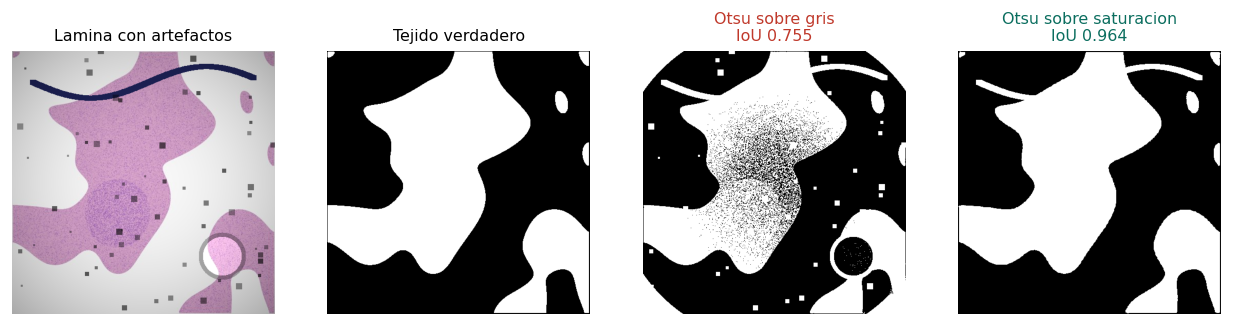

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(13, 3.7))
axes[0].imshow(sucia); axes[0].set_title('Lamina con artefactos', fontsize=9.5)
axes[1].imshow(verdad, cmap='gray'); axes[1].set_title('Tejido verdadero', fontsize=9.5)
axes[2].imshow(por_gris(sucia), cmap='gray')
axes[2].set_title(f'Otsu sobre gris\nIoU {iou(por_gris(sucia), verdad):.3f}',
                  fontsize=9.5, color=ROJO)
axes[3].imshow(por_saturacion(sucia), cmap='gray')
axes[3].set_title(f'Otsu sobre saturacion\nIoU {iou(por_saturacion(sucia), verdad):.3f}',
                  fontsize=9.5, color=VERDE)
for a in axes: a.axis('off')
plt.show()

Con la lamina limpia los dos metodos empatan (0.996 contra 0.993). Con artefactos, el
umbral sobre gris se hunde a 0.755 y el de saturacion aguanta en 0.964.

La razon es directa: **el marcador del patologo es oscuro, y para un umbral en gris,
oscuro significa tejido**. La burbuja y el vinetado tambien confunden la intensidad. La
saturacion, en cambio, mide *cuanto color* tiene el pixel — y el cristal, aunque este
sombreado, sigue siendo gris.

Ese es el motivo real de que la practica estandar en patologia digital use el espacio HSV
y no la intensidad. Con una lamina perfecta no se nota la diferencia; con una lamina real,
son 20 puntos de IoU.

Nota honesta: la saturacion tampoco resuelve el marcador — tinta azul saturada se clasifica
como tejido, y se ve como una franja en la mascara. Eliminarla requiere un paso adicional
de deteccion de color especifico.

## 5. Extraccion de parches

In [11]:
P = 256
H, W = nivel0.shape[:2]
tejido = resize(por_saturacion(sucia).astype(float), (H, W), order=0) > 0.5
ny, nx = H//P, W//P

coords = []
for i in range(ny):
    for j in range(nx):
        bloque = tejido[i*P:(i+1)*P, j*P:(j+1)*P]
        if bloque.mean() > 0.5:                 # al menos 50% de tejido
            coords.append((i*P, j*P))

total = ny*nx
print(f'parches en la rejilla        : {total}')
print(f'parches con tejido           : {len(coords)}  ({100*len(coords)/total:.1f}%)')
print(f'parches descartados          : {total-len(coords)}  ({100*(total-len(coords))/total:.1f}%)')
print(f'ahorro de computo            : {total/max(len(coords),1):.2f}x')

parches en la rejilla        : 256
parches con tejido           : 104  (40.6%)
parches descartados          : 152  (59.4%)
ahorro de computo            : 2.46x


Un 59% de los parches eran cristal. En laminillas reales la proporcion suele ser aun mayor,
porque el tejido ocupa una fraccion pequena del portaobjetos.

El umbral del 50% de tejido por parche es una decision, no una constante. Bajarlo incluye
parches de borde con poco tejido, que a veces son justo donde esta la invasion tumoral.
Subirlo los descarta. Como casi todo en este pipeline, es un compromiso que conviene
documentar.

## 6. Con datos reales

Para correr esto sobre laminillas de verdad hacen falta dos cosas.

**OpenSlide** para leer los formatos propietarios:

```bash
# Linux
sudo apt install openslide-tools
pip install openslide-python
```

```python
import openslide
lamina = openslide.OpenSlide('tumor_001.tif')
print(lamina.level_dimensions)          # las dimensiones de cada nivel
print(lamina.properties['openslide.mpp-x'])   # micras por pixel: la escala real

# leer la miniatura para el filtrado
mini = np.array(lamina.get_thumbnail((1024, 1024)))

# leer un parche del nivel 0, sin cargar la lamina entera
parche = np.array(lamina.read_region((x, y), 0, (256, 256)).convert('RGB'))
```

`read_region` es la funcion clave: lee solo esa region, decodificando unicamente las
teselas necesarias.

**Datos publicos** para no depender de material clinico:

| Base | Que trae | Util para |
|---|---|---|
| CAMELYON16/17 | Ganglio linfatico con metastasis, anotaciones pixel a pixel | Deteccion y segmentacion |
| PANDA | Biopsias de prostata con grado ISUP | Clasificacion, gradacion |
| TCGA | Miles de laminas de multiples canceres | Preentrenamiento, analisis exploratorio |

CAMELYON16 es el mejor punto de partida: trae el problema clinico completo — buscar
metastasis diminutas en un mar de tejido sano — con la verdad anotada por patologos.

Un aviso practico: una sola lamina de CAMELYON pesa entre 1 y 3 GB. Descarga dos o tres
para desarrollar, no la base completa.

## Donde falla esto

**El tejido es sintetico.** La histologia real tiene estructuras que este generador no
modela: glandulas, vasos, adipocitos, fibras de colageno orientadas. Los numeros de IoU
sobre tejido real seran menores.

**La variacion de tincion es el problema que no tocamos.** Dos laboratorios tiñen distinto,
y un modelo entrenado en uno falla en otro. Se trata con normalizacion de tincion
(Macenko, Vahadane) o con aumentacion especifica, y merece su propio tratamiento.

**No hay control de magnificacion.** Un parche de 256 px significa cosas distintas a 20x
que a 40x. En datos reales hay que leer `mpp` (micras por pixel) de los metadatos y
remuestrear a una escala comun, o el modelo aprende la escala en vez de la biologia.

**El umbral de Otsu es global.** En laminas con iluminacion muy desigual conviene un umbral
local o adaptativo.

## Referencias

- Goode A. et al. *OpenSlide: A vendor-neutral software foundation for digital pathology.*
  Journal of Pathology Informatics, 2013.
- Bejnordi B.E. et al. *Diagnostic Assessment of Deep Learning Algorithms for Detection of
  Lymph Node Metastases in Women With Breast Cancer (CAMELYON16).* JAMA, 2017.
- Otsu N. *A Threshold Selection Method from Gray-Level Histograms.* IEEE Trans. Systems,
  Man, and Cybernetics, 1979.